In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

Epoch 0 | Train Loss: 0.11666 | Val Loss: 0.34001
Epoch 10 | Train Loss: 0.04316 | Val Loss: 0.16923
Epoch 20 | Train Loss: 0.01492 | Val Loss: 0.06737
Epoch 30 | Train Loss: 0.01318 | Val Loss: 0.01801
Epoch 40 | Train Loss: 0.00929 | Val Loss: 0.03513
Epoch 50 | Train Loss: 0.00823 | Val Loss: 0.03570
Epoch 60 | Train Loss: 0.00624 | Val Loss: 0.01820
Epoch 70 | Train Loss: 0.00455 | Val Loss: 0.01416
Epoch 80 | Train Loss: 0.00281 | Val Loss: 0.00821
Epoch 90 | Train Loss: 0.00123 | Val Loss: 0.00312

RMSE: 1.3102
R2 Score: 0.7901
Direction Accuracy: 0.5124


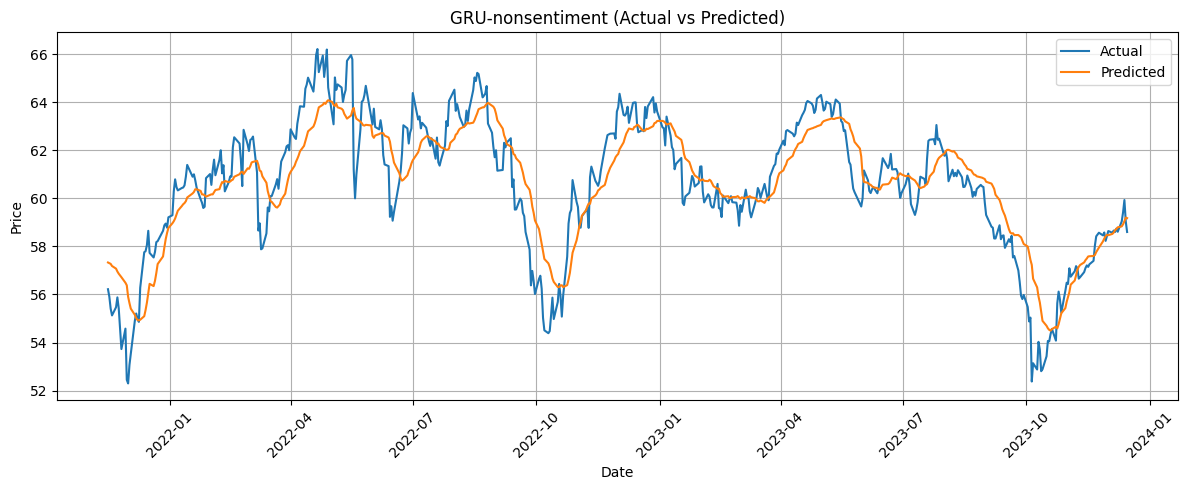

In [3]:
# LOAD DATA
df = pd.read_csv("../../Final_data/KO.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

# FEATURE ENGINEERING
df["ret1"] = df["Close"].pct_change()
df["ma5"] = df["Close"].rolling(5).mean()
df["ma10"] = df["Close"].rolling(10).mean()
df["std5"] = df["Close"].rolling(5).std()
df["lag1"] = df["Close"].shift(1)

df = df.dropna().reset_index(drop=True)

features = ["Close", "ret1", "Volume", "ma5", "ma10", "std5", "lag1"]
data = df[features].values

# SPLIT (70 / 15 / 15)
n = len(data)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

train_data = data[:train_end]
val_data   = data[train_end:val_end]
test_data  = data[val_end:]

# SCALE (NO LEAKAGE)
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_data)
val_scaled   = scaler.transform(val_data)
test_scaled  = scaler.transform(test_data)

# SEQUENCE FUNCTION
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i])
        y.append(data[i][0])  # Close price
    return np.array(X), np.array(y)

SEQ_LEN = 10

X_train, y_train = create_sequences(train_scaled, SEQ_LEN)
X_val, y_val     = create_sequences(val_scaled, SEQ_LEN)
X_test, y_test   = create_sequences(test_scaled, SEQ_LEN)

# TENSORS
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)

X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32).view(-1,1)

X_test = torch.tensor(X_test, dtype=torch.float32)

# ADD NOISE
X_train = X_train + 0.01 * torch.randn_like(X_train)

# MODEL
class SimpleGRU(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.gru = nn.GRU(input_size=input_size, hidden_size=96, batch_first=True)
        self.fc = nn.Sequential(
            nn.Linear(96, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        return self.fc(out)

model = SimpleGRU(input_size=len(features))

# TRAINING
criterion = nn.HuberLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

EPOCHS = 100
best_val_loss = float("inf")

for epoch in range(EPOCHS):

    model.train()
    pred = model(X_train)
    loss = criterion(pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # validation
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val)
        val_loss = criterion(val_pred, y_val).item()

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()

    if epoch % 10 == 0:
        print(f"Epoch {epoch} | Train Loss: {loss.item():.5f} | Val Loss: {val_loss:.5f}")

# LOAD BEST MODEL
model.load_state_dict(best_model_state)

# TEST PREDICTION
model.eval()
with torch.no_grad():
    preds = model(X_test).numpy()

# INVERSE SCALING (CORRECT WAY)
dummy = np.zeros((len(preds), len(features)))
dummy[:, 0] = preds.flatten()
preds = scaler.inverse_transform(dummy)[:, 0].reshape(-1,1)

dummy_actual = np.zeros((len(y_test), len(features)))
dummy_actual[:, 0] = y_test.flatten()
actual = scaler.inverse_transform(dummy_actual)[:, 0].reshape(-1,1)

# BIAS CORRECTION (KEY STEP)
bias = np.mean(actual - preds)
preds = preds + bias

# METRIC
rmse = np.sqrt(mean_squared_error(actual, preds))

r2 = r2_score(actual, preds)

direction_acc = np.mean(
    np.sign(np.diff(actual.flatten())) == 
    np.sign(np.diff(preds.flatten()))
)

print("\nRMSE:", round(rmse,4))
print("R2 Score:", round(r2,4))
print("Direction Accuracy:", round(direction_acc,4))

# PLOT
dates = df["Date"].iloc[-len(actual):]

plt.figure(figsize=(12,5))

plt.plot(dates, actual, label="Actual")
plt.plot(dates, preds, label="Predicted")

plt.title("GRU-nonsentiment (Actual vs Predicted)")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()